In [1]:
!git clone https://github.com/RudraKsh0091/AI-Image-Impainting.git
%cd AI-Image-Impainting
!pip install -r requirements.txt

Cloning into 'AI-Image-Impainting'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 153 (delta 83), reused 87 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 2.21 MiB | 21.73 MiB/s, done.
Resolving deltas: 100% (83/83), done.
Filtering content: 100% (3/3), 974.75 MiB | 22.81 MiB/s, done.
/kaggle/working/AI-Image-Impainting


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


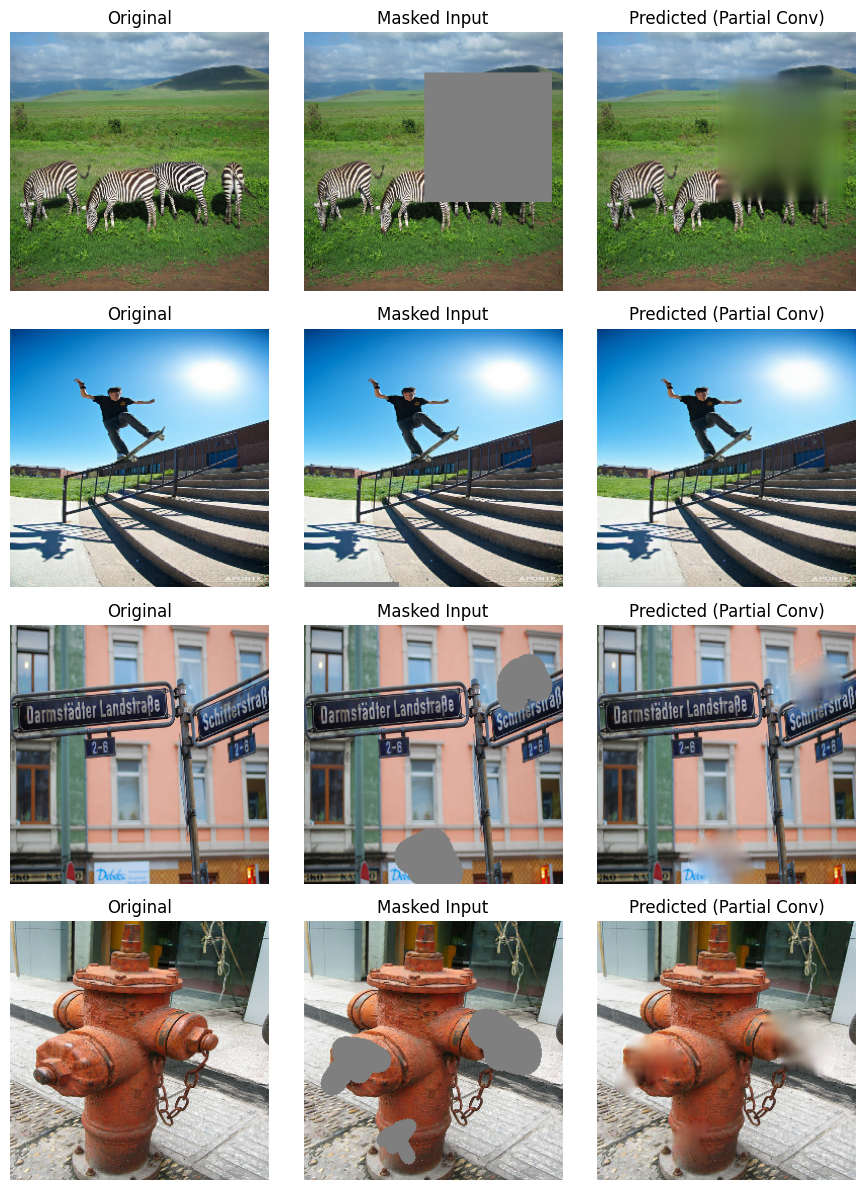

In [4]:
from src.model import build_pconv_unet
from src.data import get_train_val_split, load_dataset
from src import config
import numpy as np
import matplotlib.pyplot as plt

model = build_pconv_unet(img_size=config.IMG_SIZE)
model.load_weights("models/best_model_pconv.weights.h5")

_, val_paths = get_train_val_split(config.IMAGE_DIR, num_train=config.NUM_TRAIN, num_val=config.NUM_VAL)
val_ds = load_dataset(val_paths[:8], img_size=config.IMG_SIZE, batch_size=8, mask_type='combined', fixed_seed=123)

for (masked_images, masks), originals in val_ds.take(1):
    predictions = model.predict([masked_images, masks])
    break

def denormalize_image(img):
    img = (img + 1.0) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

num_samples = 4
fig, axes = plt.subplots(num_samples, 3, figsize=(9, num_samples * 3))

for i in range(num_samples):
    original = denormalize_image(originals[i].numpy())
    masked = denormalize_image(masked_images[i].numpy())
    predicted = denormalize_image(predictions[i])

    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(masked)
    axes[i, 1].set_title("Masked Input")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(predicted)
    axes[i, 2].set_title("Predicted (Partial Conv)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("evaluation_grid_pconv.png", dpi=150)
plt.show()